# LAB 01

The work follows the same EDA flow as the reference notebook:

1. Load and inspect data
2. Check missing values
3. Clean and standardise data
4. Detect outliers
5. Visualise distributions, trends, and relationships
6. Write plain-language conclusions



In [1]:
# Hide warning messages so the notebook output stays clean.
import warnings
warnings.filterwarnings("ignore")

# Core libraries used in this EDA lab.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Make charts and tables easier to read.
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", None)

# File locations. Keeping paths in variables makes them easy to change later.
AIR_FILE = "city_day.csv/city_day.csv"
CROP_FILE = "crop_production.csv/crop_production.csv"


def plot_missing_percent(data, title, top_n=10):
    """Plot the columns with the highest missing-value percentage."""
    missing_percent = (data.isna().mean() * 100).sort_values(ascending=False)
    missing_percent = missing_percent[missing_percent > 0].head(top_n)

    if missing_percent.empty:
        print(f"No missing values found in {title}.")
        return

    plt.figure(figsize=(10, 4))
    sns.barplot(x=missing_percent.values, y=missing_percent.index, color="#4C78A8")
    plt.title(title)
    plt.xlabel("Missing values (%)")
    plt.ylabel("Column")
    plt.xlim(0, max(100, missing_percent.max() + 5))
    plt.tight_layout()
    plt.show()


def plot_missing_before_after(before, after, title, top_n=10):
    """Compare missing-value counts before and after cleaning."""
    comparison = pd.DataFrame({
        "Before": before,
        "After": after
    })
    comparison = comparison[comparison["Before"] > 0]
    comparison = comparison.sort_values("Before", ascending=False).head(top_n)

    if comparison.empty:
        print(f"No missing values to compare for {title}.")
        return

    plot_data = comparison.reset_index(names="Column").melt(
        id_vars="Column",
        var_name="Stage",
        value_name="Missing values"
    )

    plt.figure(figsize=(10, 4))
    sns.barplot(data=plot_data, x="Missing values", y="Column", hue="Stage")
    plt.title(title)
    plt.xlabel("Missing value count")
    plt.ylabel("Column")
    plt.tight_layout()
    plt.show()


## Load the datasets



In [2]:
# Load both datasets into pandas DataFrames.
air_raw = pd.read_csv(AIR_FILE)
crop_raw = pd.read_csv(CROP_FILE)

# Shape means: (number of rows, number of columns).
print("Air quality shape:", air_raw.shape)
display(air_raw.head())

print("Crop production shape:", crop_raw.shape)
display(crop_raw.head())


Air quality shape: (29531, 16)


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


Crop production shape: (246091, 7)


,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0


# Task 1 - First-impression data profile



In [3]:
def show_basic_profile(data, title):
    """Print a simple first-look profile for a DataFrame."""
    missing_count = data.isna().sum()
    missing_percent = (data.isna().mean() * 100).round(2)

    profile_table = pd.DataFrame({
        "Data type": data.dtypes.astype(str),
        "Non-missing values": data.notna().sum(),
        "Missing values": missing_count,
        "Missing %": missing_percent,
        "Unique values": data.nunique(dropna=True)
    })

    print(f"\n{title}")
    print("Rows and columns:", data.shape)
    print("Duplicate rows:", data.duplicated().sum())

    display(profile_table)
    display(data.describe(include="all").T)

show_basic_profile(air_raw, "AIR QUALITY DATA PROFILE")
show_basic_profile(crop_raw, "CROP PRODUCTION DATA PROFILE")



AIR QUALITY DATA PROFILE
Rows and columns: (29531, 16)
Duplicate rows: 0


,Data type,Non-missing values,Missing values,Missing %,Unique values
City,str,29531,0,0.00,26
Date,str,29531,0,0.00,2009
PM2.5,float64,24933,4598,15.57,11716
PM10,float64,18391,11140,37.72,12571
NO,float64,25949,3582,12.13,5776
NO2,float64,25946,3585,12.14,7404
NOx,float64,25346,4185,14.17,8156
NH3,float64,19203,10328,34.97,5922
CO,float64,27472,2059,6.97,1779
SO2,float64,25677,3854,13.05,4761


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
City,29531,26,Ahmedabad,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date,29531,2009,2020-03-11,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PM2.5,24933.0,NaN,NaN,NaN,67.450578,64.661449,0.04,28.82,48.57,80.59,949.99
PM10,18391.0,NaN,NaN,NaN,118.127103,90.60511,0.01,56.255,95.68,149.745,1000.0
NO,25949.0,NaN,NaN,NaN,17.57473,22.785846,0.02,5.63,9.89,19.95,390.68
NO2,25946.0,NaN,NaN,NaN,28.560659,24.474746,0.01,11.75,21.69,37.62,362.21
NOx,25346.0,NaN,NaN,NaN,32.309123,31.646011,0.0,12.82,23.52,40.1275,467.63
NH3,19203.0,NaN,NaN,NaN,23.483476,25.684275,0.01,8.58,15.85,30.02,352.89
CO,27472.0,NaN,NaN,NaN,2.248598,6.962884,0.0,0.51,0.89,1.45,175.81
SO2,25677.0,NaN,NaN,NaN,14.531977,18.133775,0.01,5.67,9.16,15.22,193.86



CROP PRODUCTION DATA PROFILE
Rows and columns: (246091, 7)
Duplicate rows: 0


,Data type,Non-missing values,Missing values,Missing %,Unique values
State_Name,str,246091,0,0.00,33
District_Name,str,246091,0,0.00,646
Crop_Year,int64,246091,0,0.00,19
Season,str,246091,0,0.00,6
Crop,str,246091,0,0.00,124
Area,float64,246091,0,0.00,38442
Production,float64,242361,3730,1.52,51627


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
State_Name,246091,33,Uttar Pradesh,33306,NaN,NaN,NaN,NaN,NaN,NaN,NaN
District_Name,246091,646,BIJAPUR,945,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crop_Year,246091.0,NaN,NaN,NaN,2005.643018,4.952164,1997.0,2002.0,2006.0,2010.0,2015.0
Season,246091,6,Kharif,95951,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crop,246091,124,Rice,15104,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Area,246091.0,NaN,NaN,NaN,12002.820864,50523.404019,0.04,80.0,582.0,4392.0,8580100.0
Production,242361.0,NaN,NaN,NaN,582503.442251,17065813.17241,0.0,88.0,729.0,7023.0,1250800000.0


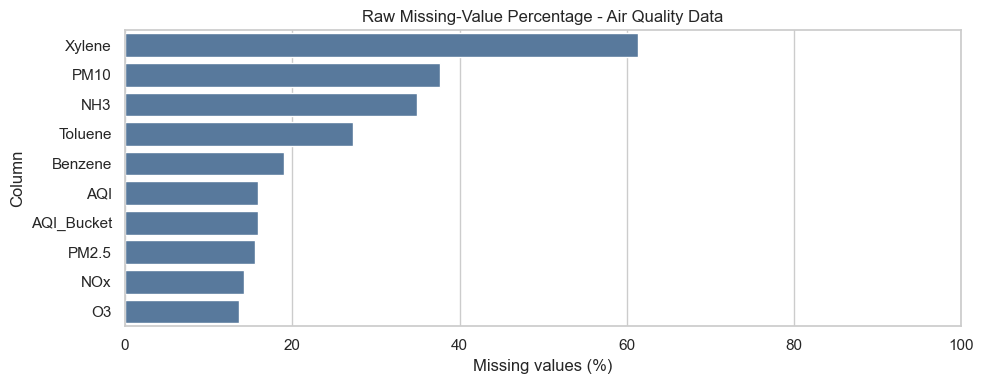

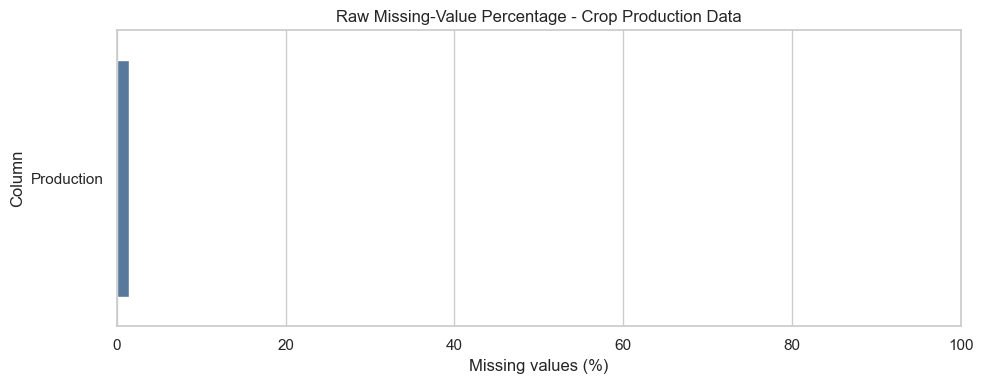

In [4]:
# Visual missingness profile for quick inspection.
plot_missing_percent(air_raw, "Raw Missing-Value Percentage - Air Quality Data")
plot_missing_percent(crop_raw, "Raw Missing-Value Percentage - Crop Production Data")


In [5]:
# Convert the air-quality date column so pandas can understand it as a date.
air_dates = pd.to_datetime(air_raw["Date"], errors="coerce")

print("Air-quality date range:")
print(air_dates.min(), "to", air_dates.max())

print("\nCrop year range:")
print(crop_raw["Crop_Year"].min(), "to", crop_raw["Crop_Year"].max())

print("\nCities in air-quality data:", air_raw["City"].nunique())
print(sorted(air_raw["City"].dropna().unique()))

print("\nStates in crop data:", crop_raw["State_Name"].nunique())
print(sorted(crop_raw["State_Name"].dropna().unique()))


Air-quality date range:
2015-01-01 00:00:00 to 2020-07-01 00:00:00

Crop year range:
1997 to 2015

Cities in air-quality data: 26
['Ahmedabad', 'Aizawl', 'Amaravati', 'Amritsar', 'Bengaluru', 'Bhopal', 'Brajrajnagar', 'Chandigarh', 'Chennai', 'Coimbatore', 'Delhi', 'Ernakulam', 'Gurugram', 'Guwahati', 'Hyderabad', 'Jaipur', 'Jorapokhar', 'Kochi', 'Kolkata', 'Lucknow', 'Mumbai', 'Patna', 'Shillong', 'Talcher', 'Thiruvananthapuram', 'Visakhapatnam']

States in crop data: 33
['Andaman and Nicobar Islands', 'Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'Dadra and Nagar Haveli', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu and Kashmir ', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland', 'Odisha', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana ', 'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal']


**Task 1 observation:**  
- Air data rows are **city-day samples**; crop data rows are **district-crop-year samples**.
- Columns such as `AQI`, `PM2.5`, `Area`, and `Production` are **features/attributes**.
- Air data has high **missingness**, especially in `Xylene`, `PM10`, and `NH3`.
- The datasets have a **granularity mismatch**, so direct row-wise merging is not valid.
- A common `State` feature and aggregation are required before comparison.

# Task 2 - Missing value treatment

Not all missing values should be treated the same way.




In [6]:
# Work on copies so the original raw data remains unchanged.
air = air_raw.copy()
crop = crop_raw.copy()

missing_air_before = air.isna().sum()
missing_crop_before = crop.isna().sum()

print("Missing values before treatment - air:")
display(missing_air_before.to_frame("before"))

print("Missing values before treatment - crop:")
display(missing_crop_before.to_frame("before"))


Missing values before treatment - air:


,before
City,0
Date,0
PM2.5,4598
PM10,11140
NO,3582
NO2,3585
NOx,4185
NH3,10328
CO,2059
SO2,3854


Missing values before treatment - crop:


,before
State_Name,0
District_Name,0
Crop_Year,0
Season,0
Crop,0
Area,0
Production,3730


Missing values after treatment - air:


,after
City,0
Date,0
PM2.5,0
PM10,0
NO,0
NO2,0
NOx,0
NH3,0
CO,0
SO2,0


Missing values after treatment - crop:


,after
State_Name,0
District_Name,0
Crop_Year,0
Season,0
Crop,0
Area,0
Production,0


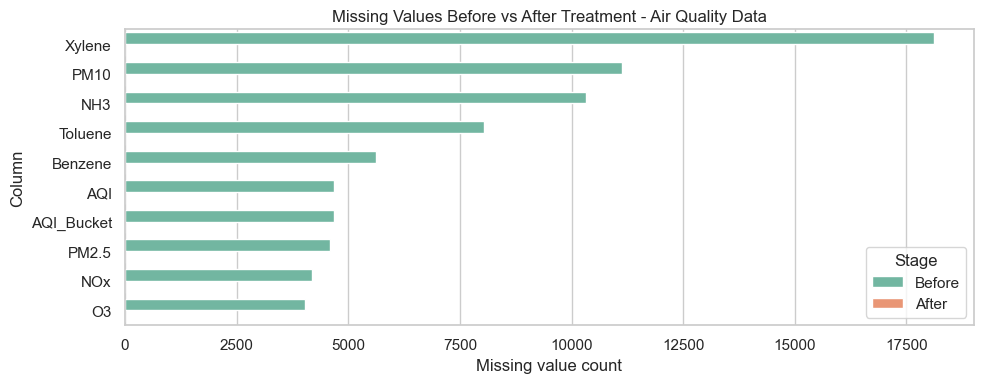

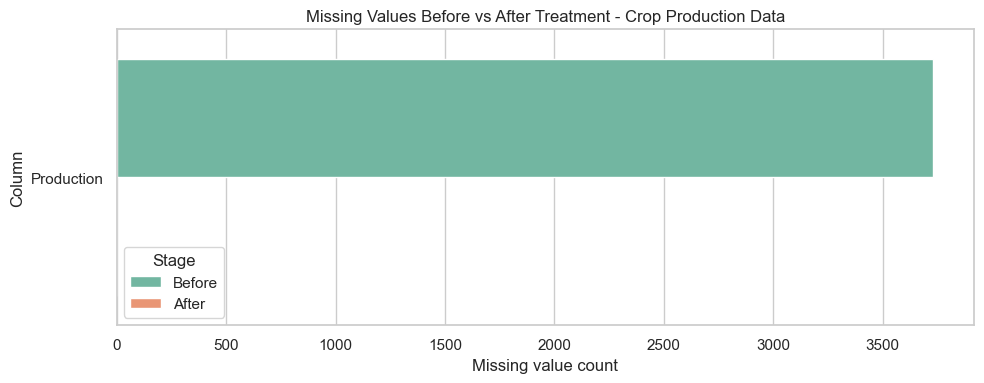

In [7]:
# Convert Date to datetime before creating year/month features later.
air["Date"] = pd.to_datetime(air["Date"], errors="coerce")

# Fill missing air-quality numeric values city by city.
# Reason: each city has its own typical pollution level.
air_numeric_columns = air.select_dtypes(include=np.number).columns.tolist()

for column in air_numeric_columns:
    city_median_values = air.groupby("City")[column].transform("median")
    air[column] = air[column].fillna(city_median_values)

    # Backup fill: if a city has all missing values for a column, use the overall median.
    overall_median = air[column].median()
    air[column] = air[column].fillna(overall_median)


def convert_aqi_to_bucket(aqi_value):
    """Convert numeric AQI into the standard AQI category."""
    if pd.isna(aqi_value):
        return np.nan
    if aqi_value <= 50:
        return "Good"
    if aqi_value <= 100:
        return "Satisfactory"
    if aqi_value <= 200:
        return "Moderate"
    if aqi_value <= 300:
        return "Poor"
    if aqi_value <= 400:
        return "Very Poor"
    return "Severe"

# Rebuild AQI_Bucket after filling missing AQI values.
air["AQI_Bucket"] = air["AQI"].apply(convert_aqi_to_bucket)

# Fill missing crop production using the median for the same state and crop.
state_crop_median = crop.groupby(["State_Name", "Crop"])["Production"].transform("median")
crop["Production"] = crop["Production"].fillna(state_crop_median)

# Backup fill for any remaining missing production values.
crop["Production"] = crop["Production"].fillna(crop["Production"].median())

missing_air_after = air.isna().sum()
missing_crop_after = crop.isna().sum()

print("Missing values after treatment - air:")
display(missing_air_after.to_frame("after"))

print("Missing values after treatment - crop:")
display(missing_crop_after.to_frame("after"))

plot_missing_before_after(
    missing_air_before,
    missing_air_after,
    "Missing Values Before vs After Treatment - Air Quality Data"
)
plot_missing_before_after(
    missing_crop_before,
    missing_crop_after,
    "Missing Values Before vs After Treatment - Crop Production Data"
)


**Task 2 observation:**  
- Numeric columns were treated as **quantitative features**.
- Text columns such as city, state, crop, and season were treated as **nominal categorical features**.
- I used **median imputation** because AQI and production values are skewed and outlier-prone.
- Air values were filled using **city-wise medians**.
- Crop `Production` was filled using **state-crop medians**.
- This preserves rows while reducing missing-value bias.

# Task 3 - State-name standardisation and duplicate removal



In [8]:
# The air dataset has cities, but the crop dataset has states.
# This dictionary lets us add a State column to the air dataset.
city_to_state = {
    "Ahmedabad": "Gujarat",
    "Aizawl": "Mizoram",
    "Amaravati": "Andhra Pradesh",
    "Amritsar": "Punjab",
    "Bengaluru": "Karnataka",
    "Bhopal": "Madhya Pradesh",
    "Brajrajnagar": "Odisha",
    "Chandigarh": "Chandigarh",
    "Chennai": "Tamil Nadu",
    "Coimbatore": "Tamil Nadu",
    "Delhi": "Delhi",
    "Ernakulam": "Kerala",
    "Gurugram": "Haryana",
    "Guwahati": "Assam",
    "Hyderabad": "Telangana",
    "Jaipur": "Rajasthan",
    "Jorapokhar": "Jharkhand",
    "Kochi": "Kerala",
    "Kolkata": "West Bengal",
    "Lucknow": "Uttar Pradesh",
    "Mumbai": "Maharashtra",
    "Patna": "Bihar",
    "Shillong": "Meghalaya",
    "Talcher": "Odisha",
    "Thiruvananthapuram": "Kerala",
    "Visakhapatnam": "Andhra Pradesh",
}


def standardize_state_name(state_name):
    """Remove spacing problems and fix known state-name variations."""
    if pd.isna(state_name):
        return state_name

    cleaned_name = str(state_name).strip()

    known_fixes = {
        "Orissa": "Odisha",
        "NCT of Delhi": "Delhi",
        "Delhi": "Delhi",
    }

    return known_fixes.get(cleaned_name, cleaned_name)

# Create matching State columns in both datasets.
air["State"] = air["City"].map(city_to_state).apply(standardize_state_name)
crop["State"] = crop["State_Name"].apply(standardize_state_name)

cleaning_notes = pd.DataFrame({
    "Issue found": [
        "Air-quality data has no State column",
        "Some crop state names contain extra spaces",
        "Some old or alternate state names may not match",
        "Air data is city-level, crop data is state/district-level"
    ],
    "Fix applied": [
        "Mapped City to State using a city-state dictionary",
        "Used strip() to remove leading/trailing spaces",
        "Used a small dictionary for known name fixes",
        "Aggregated both datasets before merging"
    ]
})

display(cleaning_notes)

unmapped_cities = sorted(air.loc[air["State"].isna(), "City"].dropna().unique())
print("Unmapped cities:", unmapped_cities)


,Issue found,Fix applied
0,Air-quality data has no State column,Mapped City to State using a city-state dictio...
1,Some crop state names contain extra spaces,Used strip() to remove leading/trailing spaces
2,Some old or alternate state names may not match,Used a small dictionary for known name fixes
3,"Air data is city-level, crop data is state/dis...",Aggregated both datasets before merging


Unmapped cities: []


In [9]:
# Remove exact duplicate rows and show how many were removed.
air_rows_before = len(air)
crop_rows_before = len(crop)

air = air.drop_duplicates()
crop = crop.drop_duplicates()

record_counts = pd.DataFrame({
    "Dataset": ["air", "crop"],
    "Rows before": [air_rows_before, crop_rows_before],
    "Rows after": [len(air), len(crop)],
    "Duplicates removed": [air_rows_before - len(air), crop_rows_before - len(crop)]
})

display(record_counts)

print("States available in cleaned air data:")
print(sorted(air["State"].dropna().unique()))


,Dataset,Rows before,Rows after,Duplicates removed
0,air,29531,29531,0
1,crop,246091,246091,0


States available in cleaned air data:
['Andhra Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Delhi', 'Gujarat', 'Haryana', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Meghalaya', 'Mizoram', 'Odisha', 'Punjab', 'Rajasthan', 'Tamil Nadu', 'Telangana', 'Uttar Pradesh', 'West Bengal']


**Task 3 observation:**  
- The merge key needed **standardization**.
- Air data had `City`; crop data had `State_Name`.
- I created a common `State` column using city-to-state mapping.
- I removed extra spaces using `strip()`.
- I fixed known name variants such as `Orissa` to `Odisha`.
- This prevents merge errors and duplicate state categories.

# Task 4 - AQI distribution

To answer where most cities sit on the AQI scale, I use:

- A histogram with KDE curve to show where AQI values cluster.
- A boxplot to show whether extreme high values are pulling the average upward.



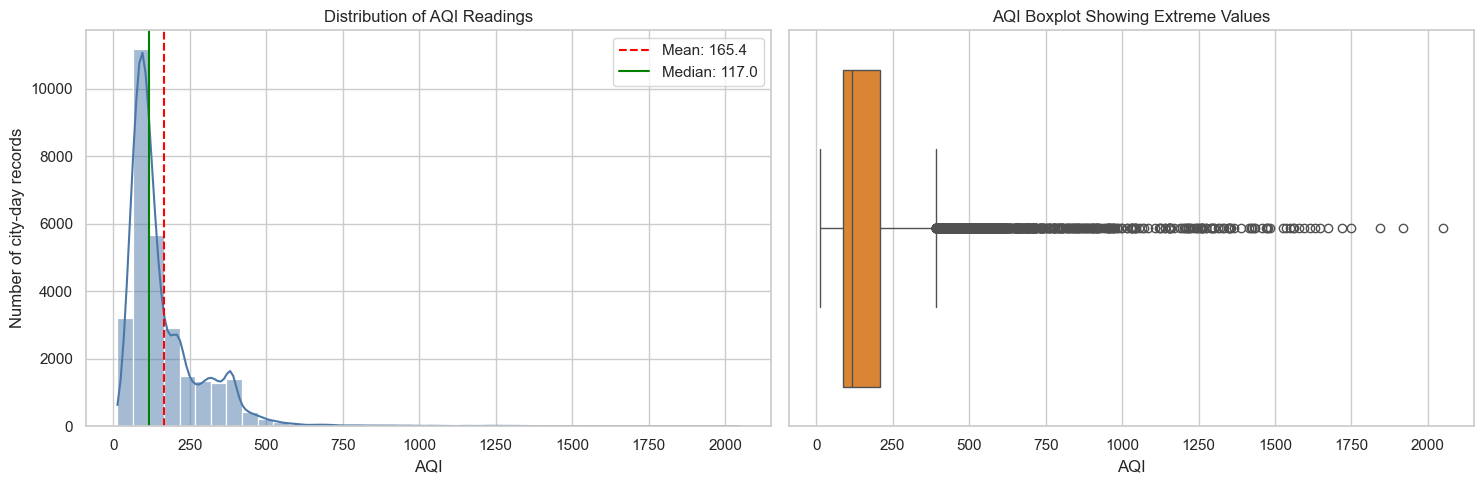

Mean AQI: 165.37
Median AQI: 117.0
AQI bucket distribution:


,count
AQI_Bucket,
Moderate,10338
Satisfactory,9979
Poor,3416
Very Poor,3012
Good,1448
Severe,1338


In [10]:
# Mean is the arithmetic average. Median is the middle value.
# Comparing them helps us see whether extreme AQI values pull the average upward.
mean_aqi = air["AQI"].mean()
median_aqi = air["AQI"].median()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(air["AQI"], bins=40, kde=True, ax=axes[0], color="#4C78A8")
axes[0].axvline(mean_aqi, color="red", linestyle="--", label=f"Mean: {mean_aqi:.1f}")
axes[0].axvline(median_aqi, color="green", linestyle="-", label=f"Median: {median_aqi:.1f}")
axes[0].set_title("Distribution of AQI Readings")
axes[0].set_xlabel("AQI")
axes[0].set_ylabel("Number of city-day records")
axes[0].legend()

sns.boxplot(x=air["AQI"], ax=axes[1], color="#F58518")
axes[1].set_title("AQI Boxplot Showing Extreme Values")
axes[1].set_xlabel("AQI")

plt.tight_layout()
plt.show()

print("Mean AQI:", round(mean_aqi, 2))
print("Median AQI:", round(median_aqi, 2))
print("AQI bucket distribution:")
display(air["AQI_Bucket"].value_counts().to_frame("count"))


**Task 4 observations:**  
- `AQI` is a **quantitative continuous variable**.
- A histogram is suitable because it shows the **frequency distribution**.
- The AQI distribution is **right-skewed**.
- Mean AQI is higher than median AQI, showing **positive skewness**.
- The boxplot shows **dispersion**, quartiles, and outliers.

# Task 5 - Extreme AQI values

I use the IQR method because it is simple, transparent, and less affected by skew than a standard-deviation rule. Instead of deleting extreme values, I cap them at the upper IQR boundary. This keeps the records but prevents implausibly high AQI values from dominating later statistics.


Lower bound: -97.0
Upper bound: 391.0
Extreme AQI values detected: 1465


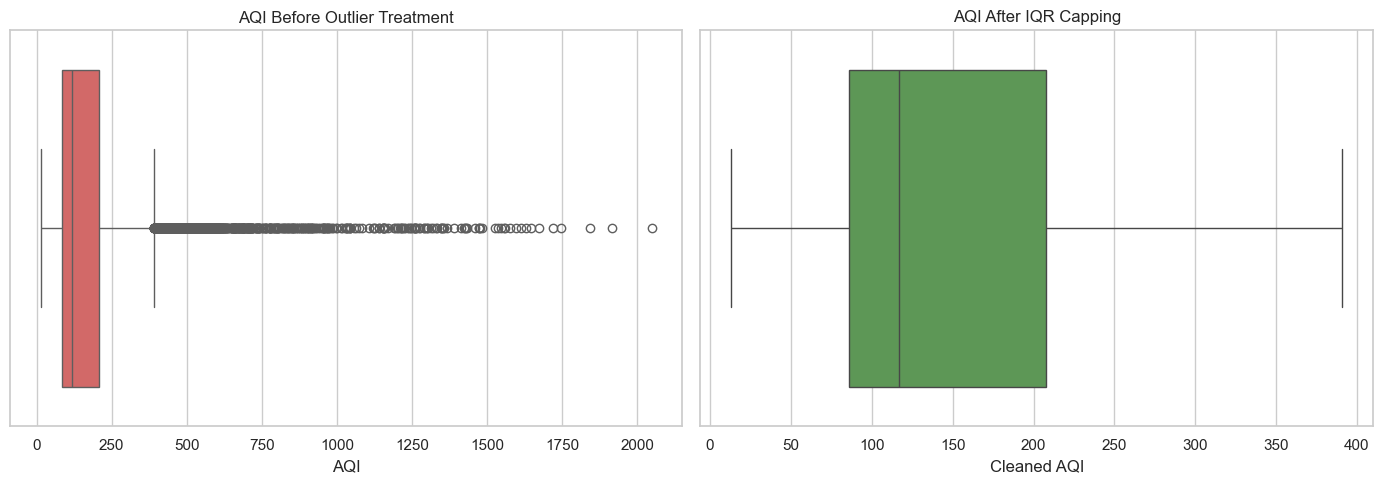

In [11]:
# IQR outlier rule:
# Values below Q1 - 1.5*IQR or above Q3 + 1.5*IQR are treated as extreme.
original_aqi = air["AQI"].copy()

q1 = air["AQI"].quantile(0.25)
q3 = air["AQI"].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

extreme_aqi_rows = (air["AQI"] < lower_bound) | (air["AQI"] > upper_bound)

print("Lower bound:", round(lower_bound, 2))
print("Upper bound:", round(upper_bound, 2))
print("Extreme AQI values detected:", int(extreme_aqi_rows.sum()))

# Cap outliers instead of deleting rows.
air["AQI_clean"] = air["AQI"].clip(lower=lower_bound, upper=upper_bound)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(x=original_aqi, ax=axes[0], color="#E45756")
axes[0].set_title("AQI Before Outlier Treatment")
axes[0].set_xlabel("AQI")

sns.boxplot(x=air["AQI_clean"], ax=axes[1], color="#54A24B")
axes[1].set_title("AQI After IQR Capping")
axes[1].set_xlabel("Cleaned AQI")

plt.tight_layout()
plt.show()


**Task 5 observation:**  
- AQI has extreme upper-tail values.
- I used the **IQR method** for outlier detection.
- IQR is robust for skewed data.
- I used **winsorization/capping** with `clip()`.
- I did not delete rows, so the sample size was preserved.
- Before-and-after boxplots show the outlier treatment clearly.

# LAB 02


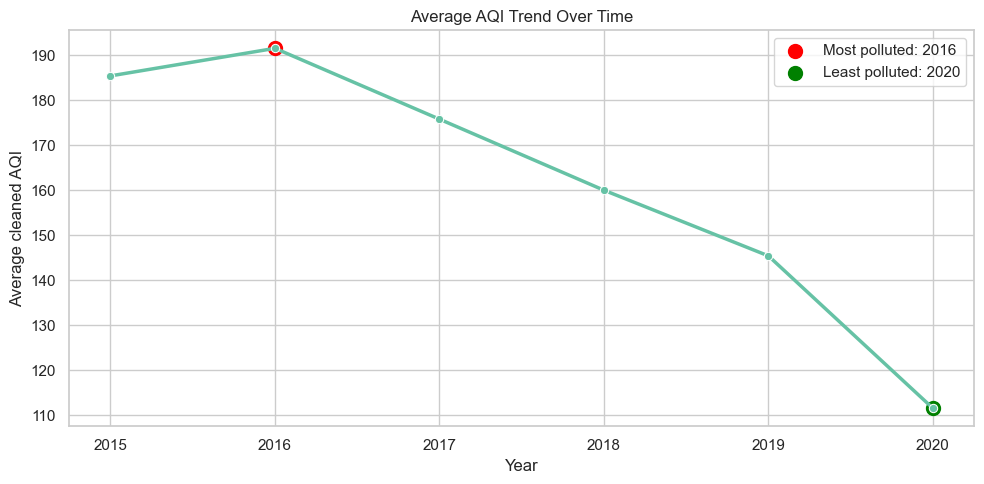

,Year,AQI_clean
0,2015,185.398072
1,2016,191.520558
2,2017,175.784816
3,2018,160.005718
4,2019,145.420830
5,2020,111.574042


In [12]:
# Create time columns from Date.
air["Year"] = air["Date"].dt.year
air["Month"] = air["Date"].dt.month

# Average cleaned AQI for each year.
yearly_aqi = air.groupby("Year", as_index=False)["AQI_clean"].mean()

most_polluted_year = yearly_aqi.loc[yearly_aqi["AQI_clean"].idxmax()]
least_polluted_year = yearly_aqi.loc[yearly_aqi["AQI_clean"].idxmin()]

plt.figure(figsize=(10, 5))
sns.lineplot(data=yearly_aqi, x="Year", y="AQI_clean", marker="o", linewidth=2.5)

plt.scatter(
    most_polluted_year["Year"],
    most_polluted_year["AQI_clean"],
    color="red",
    s=100,
    label=f"Most polluted: {int(most_polluted_year['Year'])}"
)
plt.scatter(
    least_polluted_year["Year"],
    least_polluted_year["AQI_clean"],
    color="green",
    s=100,
    label=f"Least polluted: {int(least_polluted_year['Year'])}"
)

plt.title("Average AQI Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Average cleaned AQI")
plt.legend()
plt.tight_layout()
plt.show()

display(yearly_aqi)


**Task 6 observation:**  
- This is a **descriptive time-trend analysis**, not prediction.
- I converted `Date` into datetime format.
- I extracted `Year` for **temporal aggregation**.
- A line plot is suitable for showing trends over time.
- The chart highlights the most and least polluted years.

# Task 7 - Seasonal AQI pattern

To test the NGO's October-December harvest-season claim, I compare monthly average AQI and also compare broader seasons. If October, November, and December are consistently higher, the claim is supported.


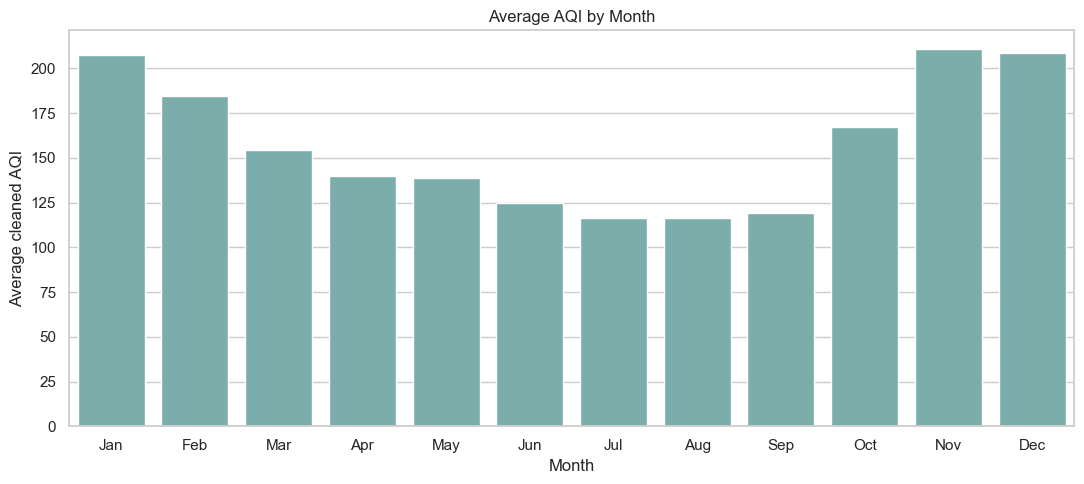

,Season_Group,AQI_clean
3,Winter (Jan-Feb),196.558094
0,Harvest/Post-monsoon (Oct-Dec),195.404703
2,Summer (Mar-May),144.327551
1,Monsoon (Jun-Sep),119.765366


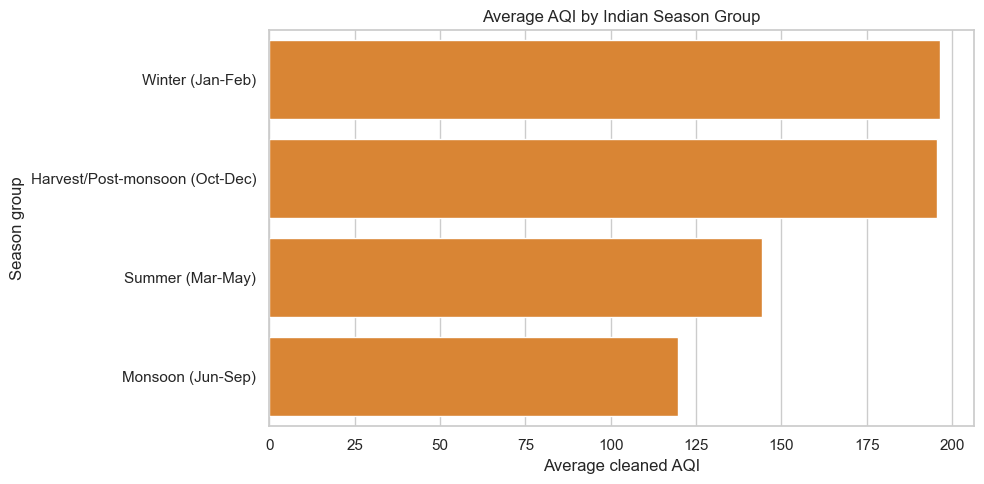

In [13]:
month_names = {
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr", 5: "May", 6: "Jun",
    7: "Jul", 8: "Aug", 9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"
}


def get_indian_season(month):
    """Group months into broad Indian seasons for AQI comparison."""
    if month in [10, 11, 12]:
        return "Harvest/Post-monsoon (Oct-Dec)"
    if month in [1, 2]:
        return "Winter (Jan-Feb)"
    if month in [3, 4, 5]:
        return "Summer (Mar-May)"
    return "Monsoon (Jun-Sep)"

# Add readable month and season labels.
air["Month_Name"] = air["Month"].map(month_names)
air["Season_Group"] = air["Month"].apply(get_indian_season)

monthly_aqi = air.groupby(["Month", "Month_Name"], as_index=False)["AQI_clean"].mean()

plt.figure(figsize=(11, 5))
sns.barplot(
    data=monthly_aqi,
    x="Month_Name",
    y="AQI_clean",
    order=list(month_names.values()),
    color="#72B7B2"
)
plt.title("Average AQI by Month")
plt.xlabel("Month")
plt.ylabel("Average cleaned AQI")
plt.tight_layout()
plt.show()

seasonal_aqi = air.groupby("Season_Group", as_index=False)["AQI_clean"].mean()
seasonal_aqi = seasonal_aqi.sort_values("AQI_clean", ascending=False)

display(seasonal_aqi)

plt.figure(figsize=(10, 5))
sns.barplot(data=seasonal_aqi, x="AQI_clean", y="Season_Group", color="#F58518")
plt.title("Average AQI by Indian Season Group")
plt.xlabel("Average cleaned AQI")
plt.ylabel("Season group")
plt.tight_layout()
plt.show()


**Task 7 observation:**  
- AQI shows **seasonality**.
- I extracted `Month` from the date feature.
- Months were grouped into Indian season categories.
- Bar charts are suitable because seasons are categorical groups.
- Harvest/post-monsoon months are important, but winter AQI is also high.
- The pattern is broader than harvest season alone.



These additional charts make the EDA more complete by showing which cities dominate pollution, which pollutants drive AQI records, whether weekdays/weekends differ, and how crop production varies by season.


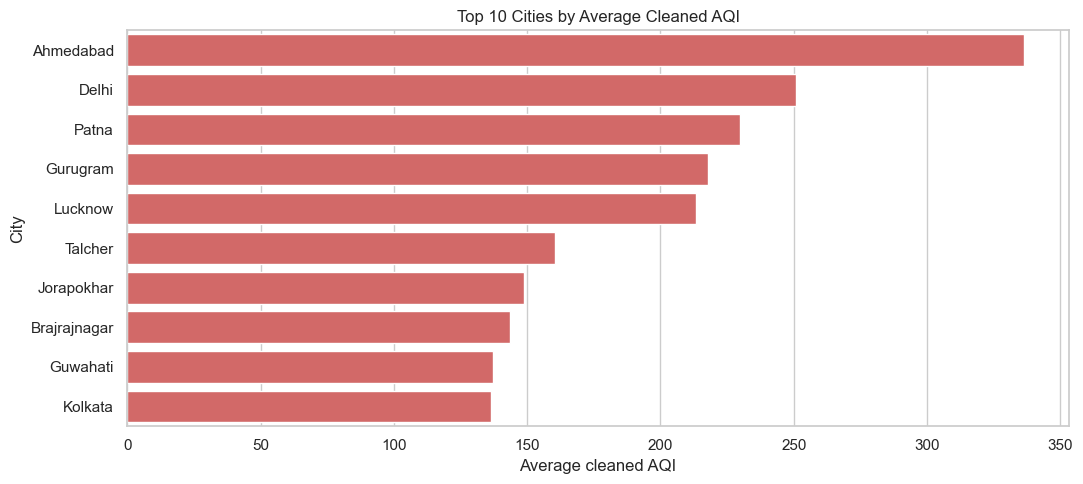

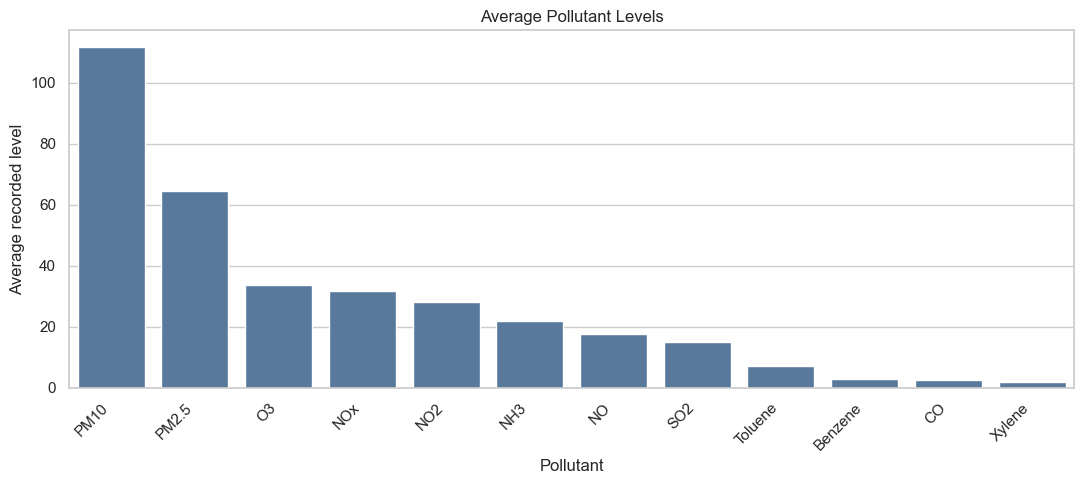

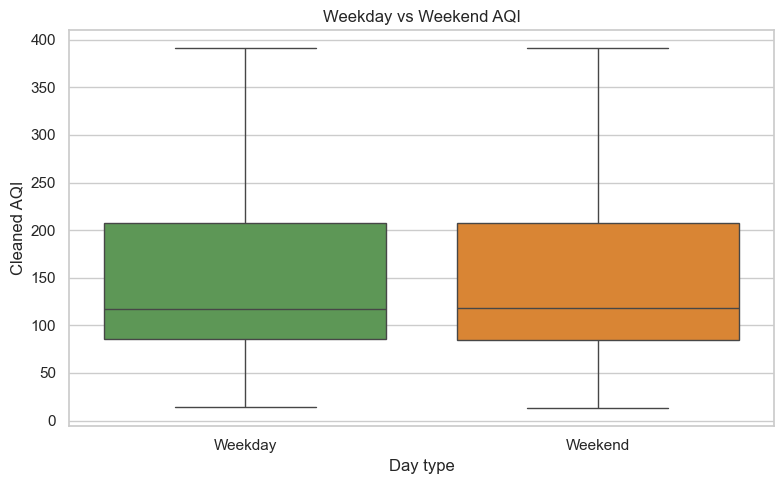

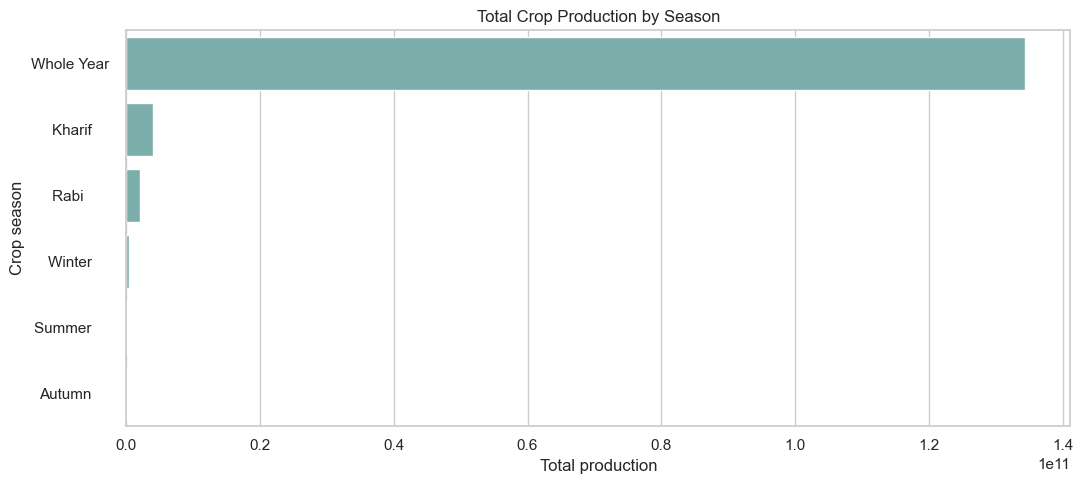

,City,AQI_clean
0,Ahmedabad,336.380040
10,Delhi,250.747138
21,Patna,229.776103
12,Gurugram,217.997618
19,Lucknow,213.469886
23,Talcher,160.404865
16,Jorapokhar,148.783576
6,Brajrajnagar,143.496802
13,Guwahati,137.151394
18,Kolkata,136.584767


,Pollutant,Average level
0,PM10,111.529814
1,PM2.5,64.495018
2,O3,33.794051
3,NOx,31.738348
4,NO2,28.038496
5,NH3,21.785599
6,NO,17.586426
7,SO2,15.120249
8,Toluene,7.250242
9,Benzene,2.879523


,Season,Production
4,Whole Year,1.344379e+11
1,Kharif,4.034225e+09
2,Rabi,2.052594e+09
5,Winter,4.345508e+08
3,Summer,1.708023e+08
0,Autumn,6.452057e+07


In [14]:
# Extra chart 1 - Top cities by average cleaned AQI
city_aqi = (
    air.groupby("City", as_index=False)["AQI_clean"]
    .mean()
    .sort_values("AQI_clean", ascending=False)
    .head(10)
)

plt.figure(figsize=(11, 5))
sns.barplot(data=city_aqi, x="AQI_clean", y="City", color="#E45756")
plt.title("Top 10 Cities by Average Cleaned AQI")
plt.xlabel("Average cleaned AQI")
plt.ylabel("City")
plt.tight_layout()
plt.show()

# Extra chart 2 - Average pollutant levels across all city-day records
pollutant_cols = ["PM2.5", "PM10", "NO", "NO2", "NOx", "NH3", "CO", "SO2", "O3", "Benzene", "Toluene", "Xylene"]
available_pollutants = [col for col in pollutant_cols if col in air.columns]

if available_pollutants:
    pollutant_means = (
        air[available_pollutants]
        .mean()
        .sort_values(ascending=False)
        .reset_index()
    )
    pollutant_means.columns = ["Pollutant", "Average level"]

    plt.figure(figsize=(11, 5))
    sns.barplot(data=pollutant_means, x="Pollutant", y="Average level", color="#4C78A8")
    plt.title("Average Pollutant Levels")
    plt.xlabel("Pollutant")
    plt.ylabel("Average recorded level")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No pollutant columns were available for the pollutant-level chart.")

# Extra chart 3 - Weekday vs weekend AQI comparison
air["Day_Type"] = np.where(air["Date"].dt.dayofweek >= 5, "Weekend", "Weekday")

plt.figure(figsize=(8, 5))
sns.boxplot(data=air, x="Day_Type", y="AQI_clean", order=["Weekday", "Weekend"], palette=["#54A24B", "#F58518"])
plt.title("Weekday vs Weekend AQI")
plt.xlabel("Day type")
plt.ylabel("Cleaned AQI")
plt.tight_layout()
plt.show()

# Extra chart 4 - Crop production by season
season_production = (
    crop.groupby("Season", as_index=False)["Production"]
    .sum()
    .sort_values("Production", ascending=False)
    .head(8)
)

plt.figure(figsize=(11, 5))
sns.barplot(data=season_production, x="Production", y="Season", color="#72B7B2")
plt.title("Total Crop Production by Season")
plt.xlabel("Total production")
plt.ylabel("Crop season")
plt.tight_layout()
plt.show()

display(city_aqi)
if available_pollutants:
    display(pollutant_means)
display(season_production)


# Task 8 - Can the two datasets talk to each other?

The datasets cannot be joined row-by-row because their levels are different:

- Air quality: city-day records
- Crop production: district/crop/year records



In [15]:
# Step 1: Convert city-day air data into state-year air data.
air_with_state_and_year = air.dropna(subset=["State", "Year"])

air_state_year = air_with_state_and_year.groupby(["State", "Year"], as_index=False).agg(
    Avg_AQI=("AQI_clean", "mean"),
    Avg_PM25=("PM2.5", "mean"),
    Avg_PM10=("PM10", "mean"),
    Avg_NO2=("NO2", "mean"),
    City_Count=("City", "nunique")
)

# Step 2: Convert district/crop/year data into state-year crop data.
crop_state_year = crop.groupby(["State", "Crop_Year"], as_index=False).agg(
    Total_Area=("Area", "sum"),
    Total_Production=("Production", "sum"),
    Crop_Count=("Crop", "nunique"),
    District_Count=("District_Name", "nunique")
)

crop_state_year = crop_state_year.rename(columns={"Crop_Year": "Year"})

# Production per area is a simple productivity measure.
# Replacing 0 area with NaN prevents divide-by-zero errors.
valid_area = crop_state_year["Total_Area"].replace(0, np.nan)
crop_state_year["Production_per_Area"] = crop_state_year["Total_Production"] / valid_area

# Step 3: Merge on the common columns: State and Year.
merged_state_year = pd.merge(
    air_state_year,
    crop_state_year,
    on=["State", "Year"],
    how="inner"
)

# Step 4: Build a state-only fallback in case exact state-year overlap is too small.
air_state = air_state_year.groupby("State", as_index=False).agg(
    Avg_AQI=("Avg_AQI", "mean"),
    Avg_PM25=("Avg_PM25", "mean"),
    Avg_PM10=("Avg_PM10", "mean"),
    Avg_NO2=("Avg_NO2", "mean"),
    City_Count=("City_Count", "max"),
    Air_Years=("Year", "nunique")
)

crop_state = crop_state_year.groupby("State", as_index=False).agg(
    Total_Area=("Total_Area", "mean"),
    Total_Production=("Total_Production", "mean"),
    Production_per_Area=("Production_per_Area", "mean"),
    Crop_Count=("Crop_Count", "max"),
    District_Count=("District_Count", "max"),
    Crop_Years=("Year", "nunique")
)

merged_state = pd.merge(air_state, crop_state, on="State", how="inner")

if len(merged_state_year) > 0:
    merged = merged_state_year.copy()
    merge_level = "State-Year"
else:
    merged = merged_state.copy()
    merge_level = "State fallback"

print("Air state-year shape:", air_state_year.shape)
print("Crop state-year shape:", crop_state_year.shape)
print("Exact State-Year merged shape:", merged_state_year.shape)
print("State-level fallback merged shape:", merged_state.shape)
print("Analysis level being used:", merge_level)

if "Year" in merged.columns:
    print("Years available after exact merge:", sorted(merged["Year"].unique()))

display(merged.head())


Air state-year shape: (91, 7)
Crop state-year shape: (519, 7)
Exact State-Year merged shape: (0, 12)
State-level fallback merged shape: (20, 13)
Analysis level being used: State fallback


,State,Avg_AQI,Avg_PM25,Avg_PM10,Avg_NO2,City_Count,Air_Years,Total_Area,Total_Production,Production_per_Area,Crop_Count,District_Count,Crop_Years
0,Andhra Pradesh,104.714579,42.327271,91.348995,31.903662,2,5,7.308102e+06,9.624820e+08,129.114799,59,13,18
1,Assam,142.247923,65.824917,118.804196,13.751048,1,2,3.909931e+06,1.173195e+08,34.553641,35,27,18
2,Bihar,226.278401,114.665775,119.250000,35.356691,1,6,7.126224e+06,2.036152e+07,2.868354,39,38,18
3,Chandigarh,102.615206,44.084711,90.374177,11.424800,1,2,9.632308e+02,4.923115e+03,5.010808,11,1,13
4,Gujarat,325.581479,63.108203,109.159116,53.428078,1,6,9.684002e+06,3.277176e+07,3.358076,29,26,16


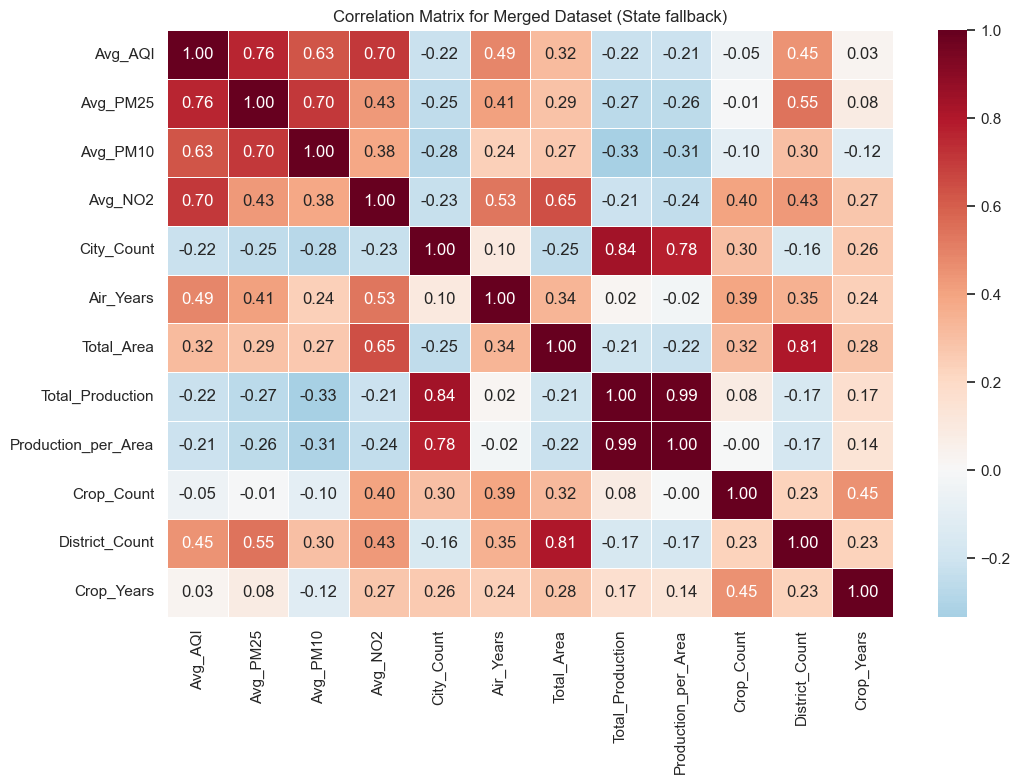

,Correlation with Avg_AQI
Avg_AQI,1.000000
Avg_PM25,0.761031
Avg_NO2,0.704289
Avg_PM10,0.627450
Air_Years,0.487525
District_Count,0.447803
Total_Area,0.316361
Crop_Years,0.026855
Crop_Count,-0.048561
Production_per_Area,-0.209777


In [16]:
# Correlation shows linear association between numeric columns.
# It does not prove cause and effect.
merged_numeric_columns = merged.select_dtypes(include=np.number).columns
correlation_matrix = merged[merged_numeric_columns].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.5
)
plt.title(f"Correlation Matrix for Merged Dataset ({merge_level})")
plt.tight_layout()
plt.show()

avg_aqi_correlations = correlation_matrix["Avg_AQI"].sort_values(ascending=False)
display(avg_aqi_correlations.to_frame("Correlation with Avg_AQI"))


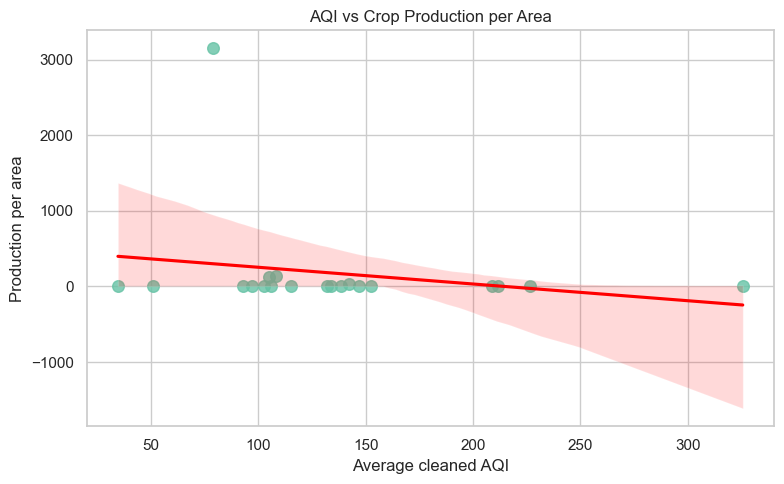

In [17]:
# Scatter plot: each point is one state-year record, or one state in fallback mode.
if len(merged) > 1:
    plt.figure(figsize=(8, 5))
    sns.regplot(
        data=merged,
        x="Avg_AQI",
        y="Production_per_Area",
        scatter_kws={"s": 70},
        line_kws={"color": "red"}
    )
    plt.title("AQI vs Crop Production per Area")
    plt.xlabel("Average cleaned AQI")
    plt.ylabel("Production per area")
    plt.tight_layout()
    plt.show()
else:
    print("The merged data has too few rows for a reliable scatter/regression plot.")


**Two relationships to discuss:**  
- `Avg_AQI` vs `Production_per_Area`: weak negative association.
- This suggests higher AQI is slightly linked with lower productivity.
- This is **correlation, not causation**.
- `Total_Area` vs `Total_Production`: expected positive structural relationship.
- `Avg_AQI` is positively related to pollutants like `Avg_PM25`, `Avg_PM10`, and `Avg_NO2`.
- These relationships support the consistency of the pollution variables.

# Task 9 - Minister briefing

- **Finding 1:** Many AQI readings are in the **moderate-to-poor** range.
- **Finding 2:** AQI has **positive skewness**; extreme values pull the mean upward.
- **Finding 3:** AQI shows **monthly and seasonal variation**.
- **Reporting point:** Use both **mean** and **median** AQI for public reporting.
- **Farmer impact:** Poor air overlaps with field work, transport, and residue-burning periods.
- **Recommendation:** Improve state-level monitoring and residue-management support in high-risk months.
- **Limitation:** This is **exploratory analysis**, not causal proof.
- **Confounders:** Crop output also depends on rainfall, irrigation, soil, crop type, pests, fertilizer, and markets.
- **Conclusion:** The data supports preventive action, but does not prove pollution alone reduces crop yield.

# Optional Task A - Pollution extremes and crop output



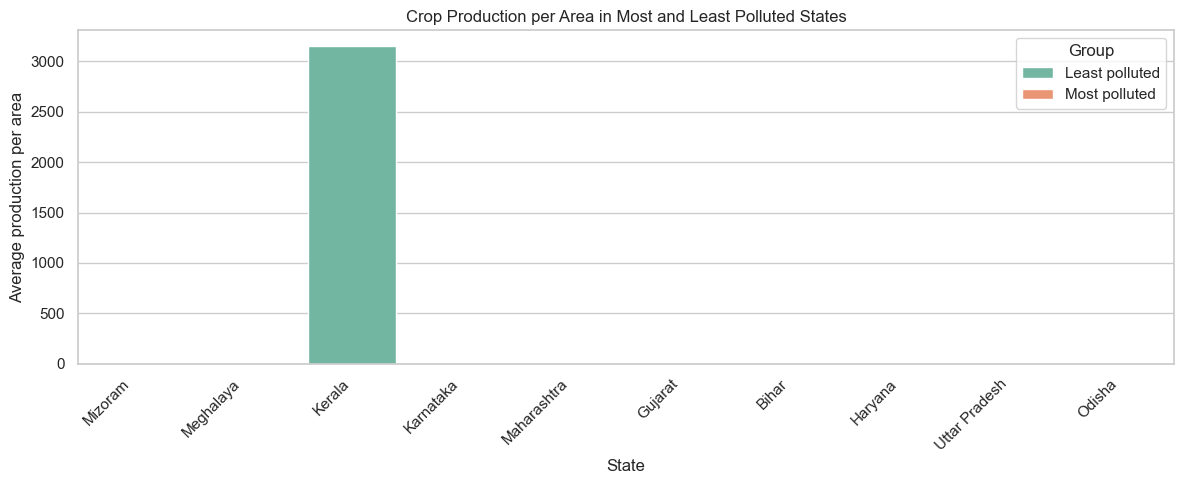

,State,Avg_AQI,Avg_Production_per_Area,Avg_Total_Production,Group
12,Mizoram,34.557522,1.657891,1.278768e+05,Least polluted
11,Meghalaya,50.978443,2.989920,6.729164e+05,Least polluted
8,Kerala,78.626690,3149.099889,5.437788e+09,Least polluted
7,Karnataka,92.723974,4.261214,4.796870e+07,Least polluted
10,Maharashtra,97.123485,3.903565,7.020885e+07,Least polluted
4,Gujarat,325.581479,3.358076,3.277176e+07,Most polluted
2,Bihar,226.278401,2.868354,2.036152e+07,Most polluted
5,Haryana,211.531161,4.410366,2.470258e+07,Most polluted
18,Uttar Pradesh,208.754703,7.555149,1.796945e+08,Most polluted
13,Odisha,152.366277,1.518298,8.479947e+06,Most polluted


In [18]:
if len(merged) >= 2:
    # Compare the five least polluted and five most polluted states.
    state_pollution = merged.groupby("State", as_index=False).agg(
        Avg_AQI=("Avg_AQI", "mean"),
        Avg_Production_per_Area=("Production_per_Area", "mean"),
        Avg_Total_Production=("Total_Production", "mean")
    )

    least_polluted_states = state_pollution.nsmallest(5, "Avg_AQI")
    least_polluted_states = least_polluted_states.assign(Group="Least polluted")

    most_polluted_states = state_pollution.nlargest(5, "Avg_AQI")
    most_polluted_states = most_polluted_states.assign(Group="Most polluted")

    pollution_extremes = pd.concat([least_polluted_states, most_polluted_states])

    plt.figure(figsize=(12, 5))
    sns.barplot(
        data=pollution_extremes,
        x="State",
        y="Avg_Production_per_Area",
        hue="Group"
    )
    plt.title("Crop Production per Area in Most and Least Polluted States")
    plt.xlabel("State")
    plt.ylabel("Average production per area")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    display(pollution_extremes)
else:
    print("Not enough merged rows for optional extreme-state comparison.")


**Optional Task A observation:**  
- This is a **grouped contrast analysis**.
- Most polluted and least polluted states were compared.
- A bar chart is suitable because pollution group is categorical.
- Productivity does not separate perfectly by pollution group.
- This suggests **confounding variables** such as rainfall, irrigation, soil, and crop mix.

# Optional Task B - Put a number on the relationship

Pearson correlation measures the direction and strength of a linear relationship. It does not prove causation.


In [19]:
if len(merged) >= 3:
    aqi_crop_correlation = merged[["Avg_AQI", "Production_per_Area"]].corr().iloc[0, 1]
    print("Correlation between Avg_AQI and Production_per_Area:", round(aqi_crop_correlation, 3))
else:
    print("Too few merged rows for a meaningful correlation value.")


Correlation between Avg_AQI and Production_per_Area: -0.21


**Optional Task B observation:**  
- Pearson correlation was used for two quantitative variables.
- `Avg_AQI` and `Production_per_Area` show a weak negative correlation.
- Correlation is about `-0.21`.
- This supports further study but not causal proof.
- Missing factors like rainfall and irrigation limit the conclusion.

# Optional Task C - One plot to rule them all

For the single most powerful visual, I choose **AQI vs Crop Production per Area**.



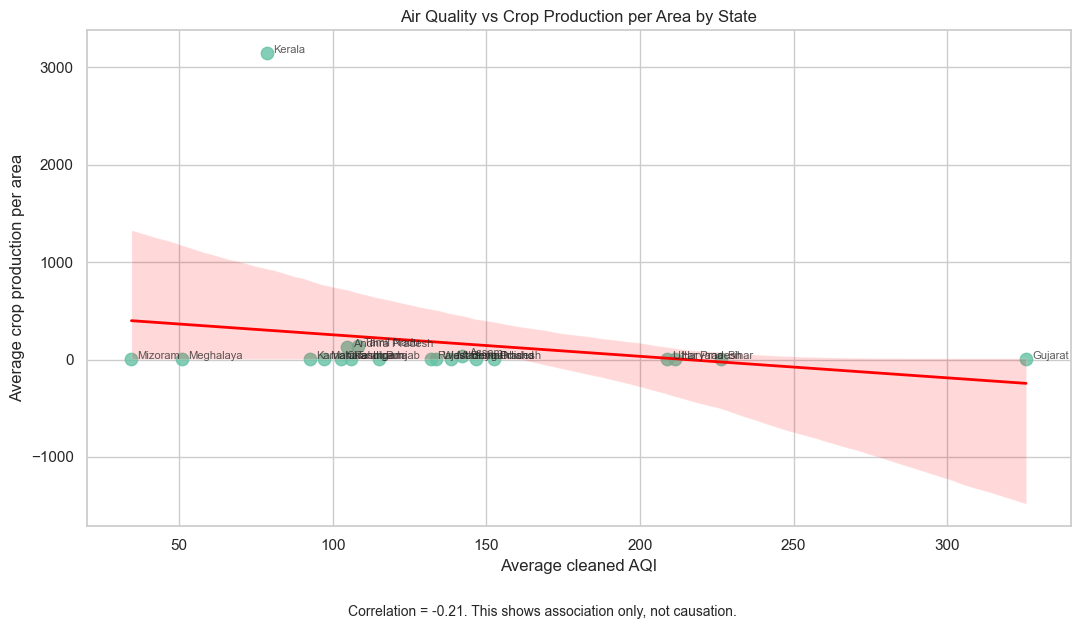

Correlation between AQI and crop production per area: -0.210


In [20]:
if len(merged) >= 2:
    final_plot_data = merged.copy()
    final_correlation = final_plot_data[["Avg_AQI", "Production_per_Area"]].corr().iloc[0, 1]

    plt.figure(figsize=(11, 6))
    sns.regplot(
        data=final_plot_data,
        x="Avg_AQI",
        y="Production_per_Area",
        scatter_kws={"s": 80, "alpha": 0.8},
        line_kws={"color": "red", "linewidth": 2}
    )

    # Label each point so the chart can be understood without a separate table.
    for _, row in final_plot_data.iterrows():
        plt.text(
            row["Avg_AQI"] + 2,
            row["Production_per_Area"],
            row["State"],
            fontsize=8,
            alpha=0.75
        )

    plt.title("Air Quality vs Crop Production per Area by State")
    plt.xlabel("Average cleaned AQI")
    plt.ylabel("Average crop production per area")
    plt.figtext(
        0.5,
        -0.04,
        f"Correlation = {final_correlation:.2f}. This shows association only, not causation.",
        ha="center",
        fontsize=10
    )
    plt.tight_layout()
    plt.show()

    print(f"Correlation between AQI and crop production per area: {final_correlation:.3f}")
else:
    print("Not enough merged records to create the final story chart.")


**Optional Task C observation:**  
- The final scatter plot shows a **bivariate relationship**.
- Each point represents one state.
- The trendline shows the overall direction of association.
- The scattered points show variation and exceptions.
- The chart is useful because it combines direction, strength, and state-level comparison.